# Análise de Comunicação — Inferência LLM Distribuída

Este notebook analisa a hipótese central do trabalho:
**o gargalo de escalabilidade no PCAD é a largura de banda da rede de interconexão**,
que limita o Tensor Parallel (TP) mas afeta menos o Pipeline Parallel (PP).

**Entrada:** `data_processed/comm_comp.csv` (gerado por `scripts/analyze_traces.py --data data/final`)  
**Saída:** figuras em `figures/communication_analysis/`

### Pré-requisito
Rodar dentro do ambiente `.#default` (que tem `nsys`):
```bash
nix develop .#default
python scripts/analyze_traces.py --data data/final
```
Depois retornar para `.#tools` para rodar este notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 11})

BASE_DIR = Path('../data_processed')
FIG_DIR  = Path('../figures/communication_analysis')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Parâmetro principal da análise de banda
TARGET_PCT    = 20    # % máximo de comunicação considerado 'compute-bound'
# Banda nominal do PCAD: Ethernet 10 GbE. O iperf3 TCP single-flow mede ~0.94 Gbps
# (teto de um stream TCP), enquanto o NCCL satura a interface a 95-97% em TP
# (ver ifutil_peak). Usamos o valor medido quando disponível; o fallback abaixo
# é a banda nominal do enlace (10 GbE).
ASSUMED_BW_GBPS = 10

STRATEGY_COLORS = {'none': '#7f7f7f', 'TP': '#d62728', 'PP': '#1f77b4'}
WORKLOAD_LS     = {'short': '--', 'long': '-'}
NODE_MARKER     = {'poti': 'o', 'tupi': 's'}

def strategy_label(s):
    return {'none': 'Single GPU', 'TP': 'TP (AllReduce)', 'PP': 'PP (SendRecv)'}.get(s, s)

## 1. Carregamento dos dados

In [2]:
comm_csv = BASE_DIR / 'comm_comp.csv'
if not comm_csv.exists():
    raise FileNotFoundError(
        f"{comm_csv} não encontrado.\n"
        "Rode primeiro (dentro do shell com nsys):\n"
        "  python scripts/analyze_traces.py --data data/final"
    )

cc = pd.read_csv(comm_csv)

# Compatibilidade: garante comp_pct_head mesmo em CSVs mais antigos
if 'comp_pct_head' not in cc.columns:
    cc['comp_pct_head'] = 100 - cc['comm_pct_head']

cc['comm_pct'] = cc['comm_pct_head']
cc['comp_pct'] = cc['comp_pct_head']
cc['config'] = cc.apply(
    lambda r: f"N{r['n_gpus']} {r['strategy'].upper()} {r['workload'].capitalize()}", axis=1
)

_order = {'none': 0, 'TP': 1, 'PP': 2}
cc['_sort'] = cc['strategy'].map(_order)
cc = cc.sort_values(['_sort', 'n_gpus', 'workload']).drop(columns='_sort').reset_index(drop=True)

print(f"Experimentos carregados: {len(cc)}")
display(cc[['run', 'n_gpus', 'strategy', 'workload', 'comm_pct',
            'dominant_collective', 'itl_ms', 'throughput_req_s', 'iperf3_gbps']])

Experimentos carregados: 14


,run,n_gpus,strategy,workload,comm_pct,dominant_collective,itl_ms,throughput_req_s,iperf3_gbps
0,N1_tupi_none_long_r1_798983,1,none,long,0.000000,NaN,17.491661,0.111244,NaN
1,N1_tupi_none_short_r1_790477,1,none,short,0.000000,NaN,18.332669,0.423106,NaN
2,N2_poti_TP_long_r1_790072,2,TP,long,58.482780,AllReduce,31.145225,0.222012,0.941274
3,N2_tupi_TP_long_r1_798983,2,TP,long,96.730594,AllReduce,23.149981,0.064990,0.941265
4,N2_poti_TP_short_r1_790073,2,TP,short,55.195466,AllReduce,30.142186,0.228258,0.941279
5,N2_tupi_TP_short_r1_796872,2,TP,short,96.944276,AllReduce,22.692790,0.292158,0.941269
6,N4_poti_TP_long_r1_790077,4,TP,long,81.461449,AllReduce,39.160995,0.173517,0.941223
7,N4_poti_TP_short_r1_790075,4,TP,short,81.598498,AllReduce,39.051290,0.173902,0.941231
8,N2_poti_PP_long_r1_790071,2,PP,long,0.237007,SendRecv,35.047521,0.220769,0.941311
9,N2_tupi_PP_long_r1_796872,2,PP,long,23.807623,SendRecv,19.707039,0.097908,0.941282


Os experimentos são divididos em três casos para o número de GPUs (1, 2 ou 4) e em duas estratégias de paralelismo: PP (Pipeline Parallelism) e TP (Tensor Parallelism).

Os experimentos com 4 GPUs foram feitos apenas com as Potis, por causa de sua maior disponibilidade.

## 2. Decomposição comunicação / computação

Um painel por cluster (`tupi` e `poti`); dentro de cada painel, as barras são agrupadas
por estratégia de particionamento e número de nós, com uma barra por workload
(short = 128/128, long = 1024/512 ISL/OSL). Cada barra mostra quanto do tempo total de
GPU (rank 0) foi gasto em kernels NCCL (comunicação) vs. demais kernels CUDA
(computação).

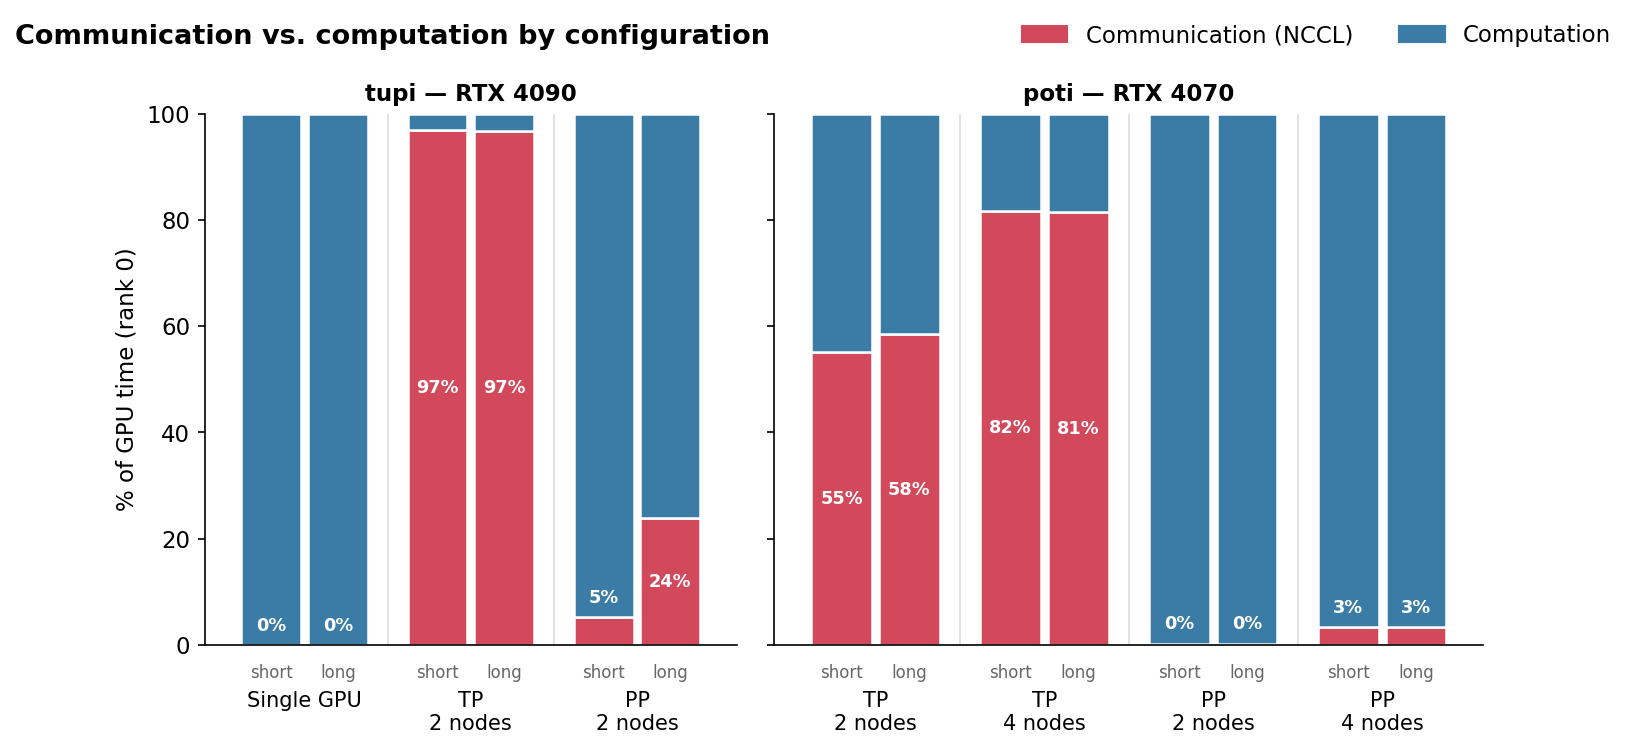

In [3]:
# Grupos (estratégia, nº de nós) na ordem de leitura; dentro de cada grupo,
# uma barra por workload (short, long)
GROUP_ORDER = [('none', 1), ('TP', 2), ('TP', 4), ('PP', 2), ('PP', 4)]
WORKLOADS   = ['short', 'long']
COLOR_COMM  = '#d1495b'
COLOR_COMP  = '#3a7ca5'

def group_label(strategy, n):
    return 'Single GPU' if strategy == 'none' else f'{strategy}\n{n} nodes'

clusters = [('tupi', 'RTX 4090'), ('poti', 'RTX 4070')]
panel_groups = {
    node: [(s, n) for (s, n) in GROUP_ORDER
           if not cc[(cc['node'] == node) & (cc['strategy'] == s)
                     & (cc['n_gpus'] == n)].empty]
    for node, _ in clusters
}

fig, axes = plt.subplots(
    1, 2, figsize=(11, 4.6), sharey=True,
    gridspec_kw={'width_ratios': [len(panel_groups[n]) for n, _ in clusters],
                 'wspace': 0.06},
)

BAR_W   = 0.36
OFFSETS = {'short': -0.5 * BAR_W - 0.02, 'long': 0.5 * BAR_W + 0.02}

for ax, (node, gpu) in zip(axes, clusters):
    sub    = cc[cc['node'] == node]
    groups = panel_groups[node]

    for gi, (strategy, n) in enumerate(groups):
        for wl in WORKLOADS:
            row = sub[(sub['strategy'] == strategy) & (sub['n_gpus'] == n)
                      & (sub['workload'] == wl)]
            if row.empty:
                continue
            row  = row.iloc[0]
            xpos = gi + OFFSETS[wl]
            ax.bar(xpos, row['comm_pct'], width=BAR_W, color=COLOR_COMM,
                   edgecolor='white', linewidth=1.2)
            ax.bar(xpos, row['comp_pct'], bottom=row['comm_pct'], width=BAR_W,
                   color=COLOR_COMP, edgecolor='white', linewidth=1.2)

            pct = row['comm_pct']
            if pct >= 12:
                ax.text(xpos, pct / 2, f'{pct:.0f}%', ha='center', va='center',
                        color='white', fontsize=8.5, fontweight='bold')
            else:
                ax.text(xpos, pct + 2, f'{pct:.0f}%', ha='center', va='bottom',
                        color='white', fontsize=8.5, fontweight='bold')

            ax.text(xpos, -3.5, wl, ha='center', va='top', fontsize=8,
                    color='#666666', clip_on=False)

    for gi in range(1, len(groups)):
        ax.axvline(gi - 0.5, color='#dddddd', linewidth=0.8, zorder=0)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([group_label(s, n) for s, n in groups], fontsize=10)
    ax.tick_params(axis='x', pad=22, length=0)
    ax.set_xlim(-0.6, len(groups) - 0.4)
    ax.set_ylim(0, 100)
    ax.set_title(f'{node} — {gpu}', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% of GPU time (rank 0)')

handles = [
    mpatches.Patch(color=COLOR_COMM, label='Communication (NCCL)'),
    mpatches.Patch(color=COLOR_COMP, label='Computation'),
]
fig.legend(handles=handles, loc='upper right', ncols=2, frameon=False,
           bbox_to_anchor=(0.99, 1.04))
fig.suptitle('Communication vs. computation by configuration', x=0.01, y=1.01,
             ha='left', fontsize=13, fontweight='bold')

fig.savefig(FIG_DIR / 'comm-comp-breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

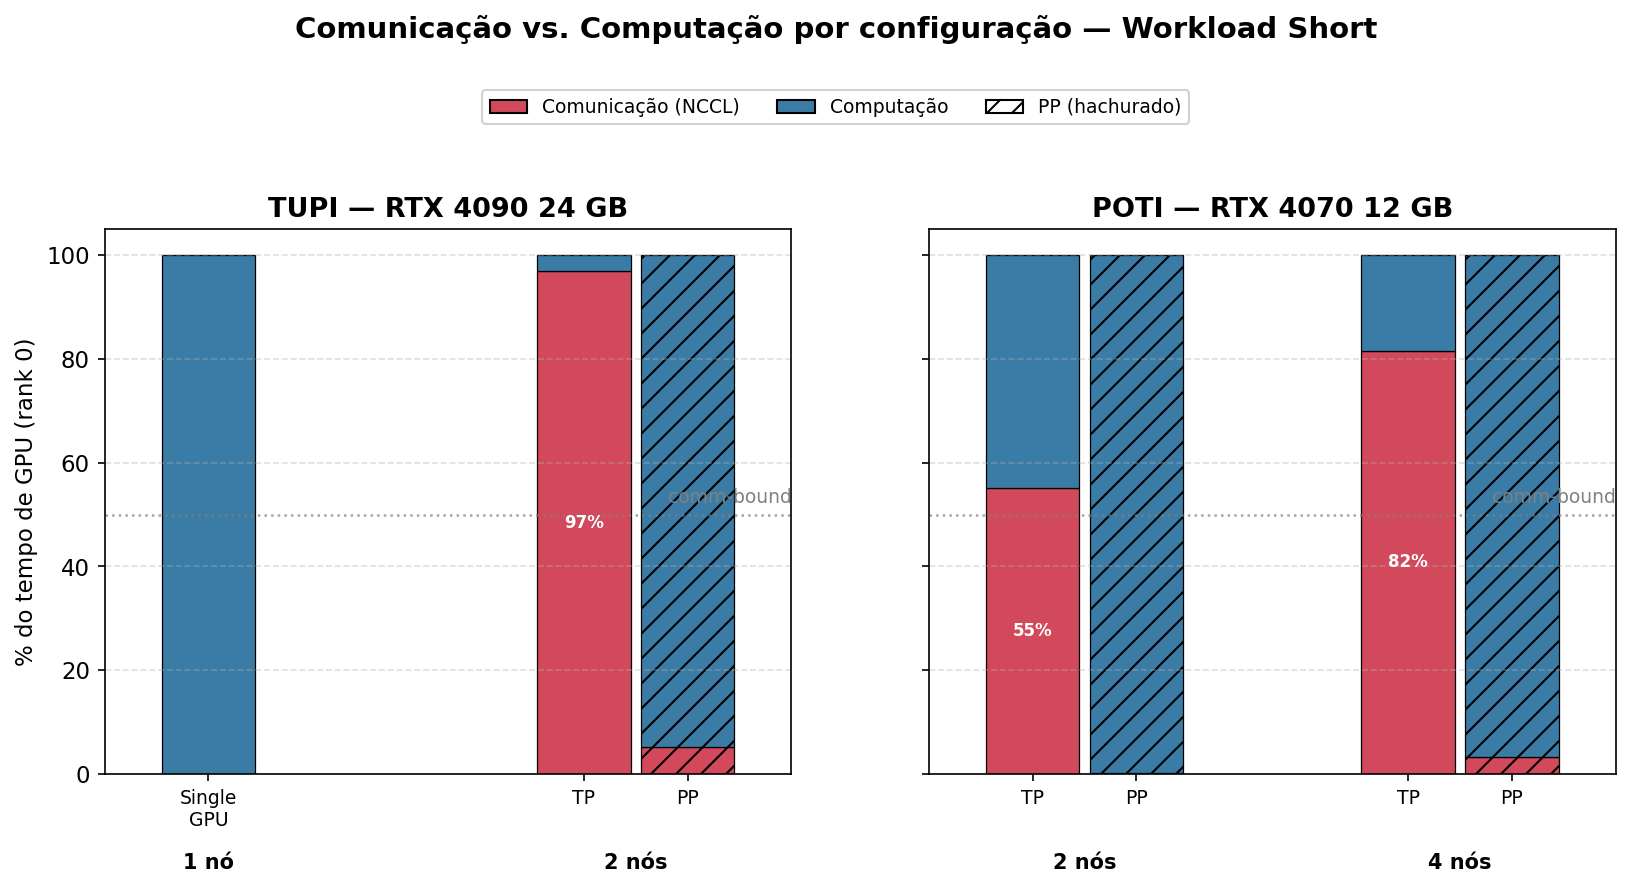

In [4]:
cc_short = cc[cc['workload'] == 'short'].reset_index(drop=True)
NODE_TITLES     = {'tupi': 'TUPI — RTX 4090 24 GB', 'poti': 'POTI — RTX 4070 12 GB'}
STRAT_ORDER     = ['none', 'TP', 'PP']
STRAT_XLABEL    = {'none': 'Single\nGPU', 'TP': 'TP', 'PP': 'PP'}
STRAT_HATCH     = {'none': '', 'TP': '', 'PP': '//'}
nodes_present   = [n for n in ['tupi', 'poti'] if n in cc_short['node'].values]

fig, axes = plt.subplots(1, len(nodes_present), figsize=(6.5 * len(nodes_present), 5.5), sharey=True)
if len(nodes_present) == 1:
    axes = [axes]

bar_w     = 0.34
group_gap = 0.55

for idx, node in enumerate(nodes_present):
    ax = axes[idx]
    sub = cc_short[cc_short['node'] == node]
    n_gpus_vals = sorted(sub['n_gpus'].unique())

    xticks, xticklabels, group_centers = [], [], []

    for gi, n in enumerate(n_gpus_vals):
        grp = sub[sub['n_gpus'] == n]
        strats = [s for s in STRAT_ORDER if s in set(grp['strategy'])]
        base_x = gi * (len(strats) * bar_w + group_gap)
        bar_centers = base_x + np.arange(len(strats)) * bar_w
        group_centers.append(bar_centers.mean())

        for xpos, strat in zip(bar_centers, strats):
            row = grp[grp['strategy'] == strat].iloc[0]
            hatch = STRAT_HATCH.get(strat, '')
            ax.bar(xpos, row['comm_pct'], width=bar_w * 0.9, color='#d1495b',
                   edgecolor='black', linewidth=0.6, hatch=hatch)
            ax.bar(xpos, row['comp_pct'], width=bar_w * 0.9, bottom=row['comm_pct'],
                   color='#3a7ca5', edgecolor='black', linewidth=0.6, hatch=hatch)
            if row['comm_pct'] >= 8:
                ax.text(xpos, row['comm_pct'] / 2, f"{row['comm_pct']:.0f}%",
                        ha='center', va='center', color='white', fontsize=8, fontweight='bold')
            xticks.append(xpos)
            xticklabels.append(STRAT_XLABEL.get(strat, strat))

    ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(xticks[-1] + bar_w, 51.5, 'comm-bound', ha='right', va='bottom', color='gray', fontsize=9)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=9)
    for gc, n in zip(group_centers, n_gpus_vals):
        ax.annotate(f'{n} nó' if n == 1 else f'{n} nós',
                    xy=(gc, 0), xycoords=('data', 'axes fraction'),
                    xytext=(0, -38), textcoords='offset points',
                    ha='center', va='top', fontsize=10, fontweight='bold',
                    annotation_clip=False)

    ax.set_xlim(min(xticks) - bar_w, max(xticks) + bar_w)
    ax.set_ylabel('% do tempo de GPU (rank 0)' if idx == 0 else '')
    ax.set_ylim(0, 105)
    ax.set_title(NODE_TITLES.get(node, node.upper()), fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

handles = [
    mpatches.Patch(facecolor='#d1495b', edgecolor='black', label='Comunicação (NCCL)'),
    mpatches.Patch(facecolor='#3a7ca5', edgecolor='black', label='Computação'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='PP (hachurado)'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.06), fontsize=9, framealpha=0.9)

fig.suptitle('Comunicação vs. Computação por configuração — Workload Short', fontsize=14, fontweight='bold', y=1.14)
fig.subplots_adjust(bottom=0.22)
fig.savefig(FIG_DIR / 'comm-comp-breakdown-short.png', dpi=150, bbox_inches='tight')
plt.show()

Em ambos os gráficos (short e long), é claramente perceptível que a estratégia TP consome muito mais tempo de GPU em comunicação do que PP — resultado esperado dado o padrão de sincronização a cada camada do TP frente às trocas pontuais do PP, mas a magnitude da diferença reforça o quanto essa comunicação domina o tempo total de execução.

## 3. TP vs PP: padrões de comunicação

- **TP (Tensor Parallel)** insere um *AllReduce* a cada camada do transformer durante
  prefill **e** decode — comunicação **fina e frequente**, proporcional a
  `hidden_size × seq_len × n_layers`.
- **PP (Pipeline Parallel)** transfere ativações nas fronteiras de estágio — comunicação
  **grossa e infrequente**, limitada ao número de cortes no modelo.

Esperamos que TP seja sistematicamente mais comm-bound que PP, e que a fração cresça
mais rápido com N no TP do que no PP.

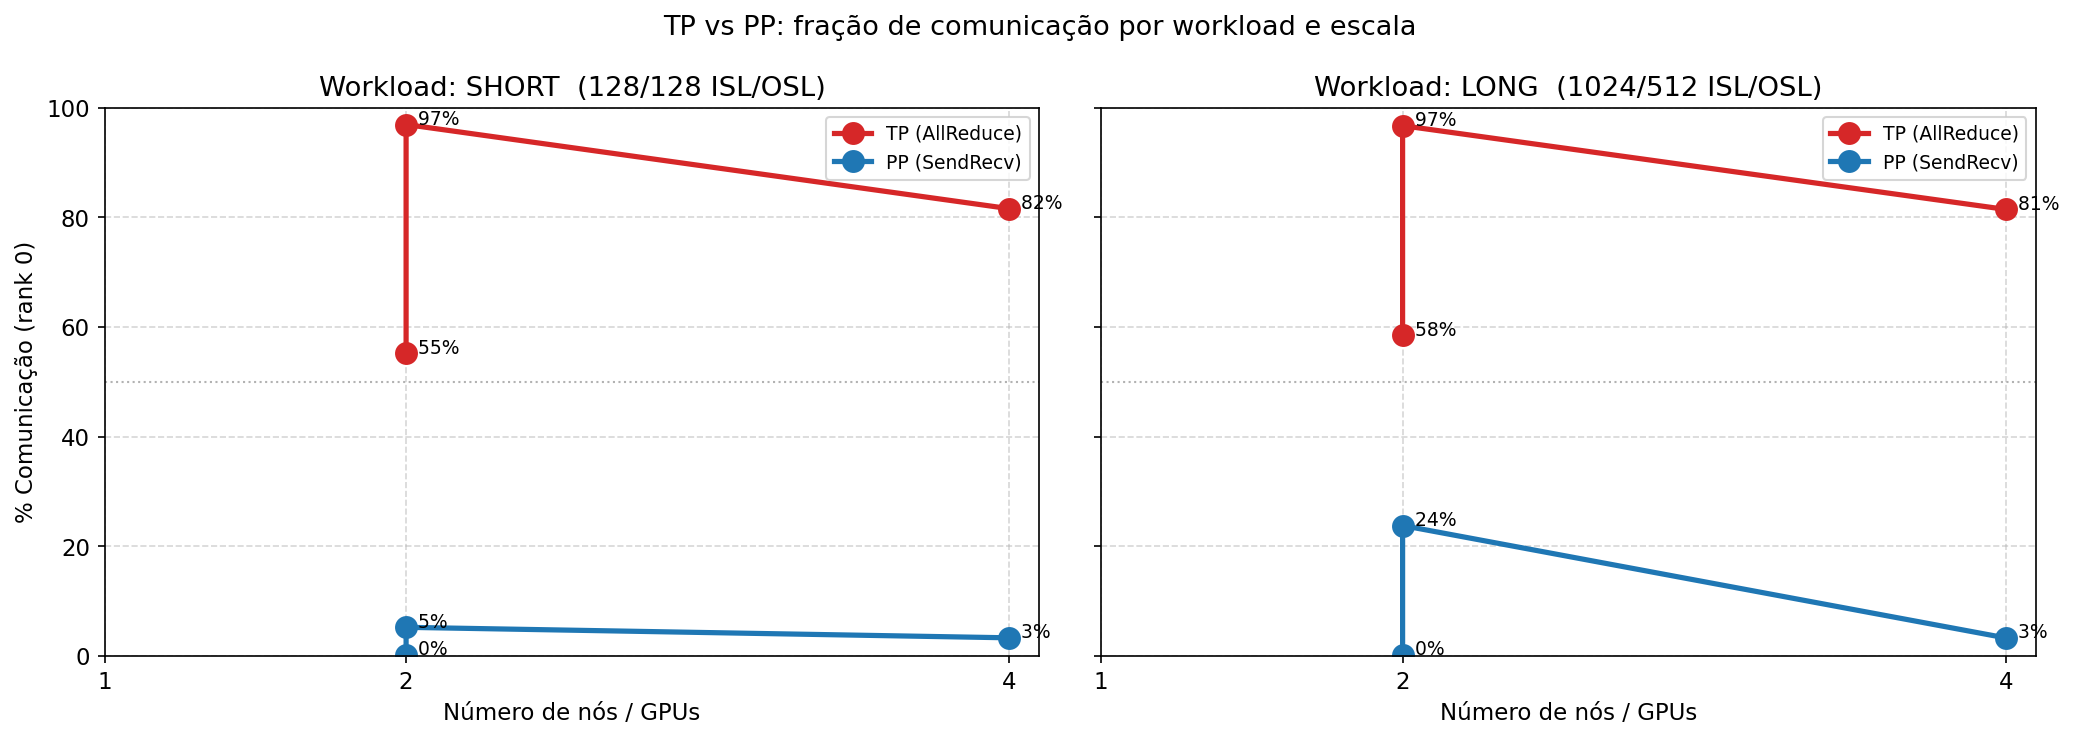

In [5]:
workloads = [w for w in ['short', 'long'] if w in cc['workload'].values]
fig, axes = plt.subplots(1, len(workloads), figsize=(7 * len(workloads), 5), sharey=True)
if len(workloads) == 1:
    axes = [axes]

for idx, wl in enumerate(workloads):
    ax = axes[idx]
    for strategy in ['TP', 'PP']:
        sub = cc[(cc['strategy'] == strategy) & (cc['workload'] == wl)].sort_values('n_gpus')
        if sub.empty:
            continue
        ax.plot(sub['n_gpus'], sub['comm_pct'],
                marker='o', linewidth=2.5, markersize=10,
                color=STRATEGY_COLORS[strategy],
                label=strategy_label(strategy))
        for _, row in sub.iterrows():
            ax.annotate(f"  {row['comm_pct']:.0f}%",
                        (row['n_gpus'], row['comm_pct']), fontsize=9)

    isl_osl = '128/128' if wl == 'short' else '1024/512'
    ax.set_title(f"Workload: {wl.upper()}  ({isl_osl} ISL/OSL)")
    ax.set_xlabel('Número de nós / GPUs')
    ax.set_ylabel('% Comunicação (rank 0)' if idx == 0 else '')
    ax.set_ylim(0, 100)
    all_n = sorted(cc['n_gpus'].unique())
    ax.set_xticks(all_n)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.5)

fig.suptitle('TP vs PP: fração de comunicação por workload e escala', fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'tp-vs-pp-comm-fraction.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Saturação da interface de rede (evidência direta)

O `%ifutil` (sar) mede a utilização da interface `192.168.*` em cada nó. Se a comunicação
é o gargalo, o tráfego do *AllReduce* (TP) deve saturar o enlace, enquanto o *SendRecv*
(PP) o usa pouco. A correlação de Pearson entre `comm_pct` e `ifutil_peak` é a evidência
**mais direta** da tese.

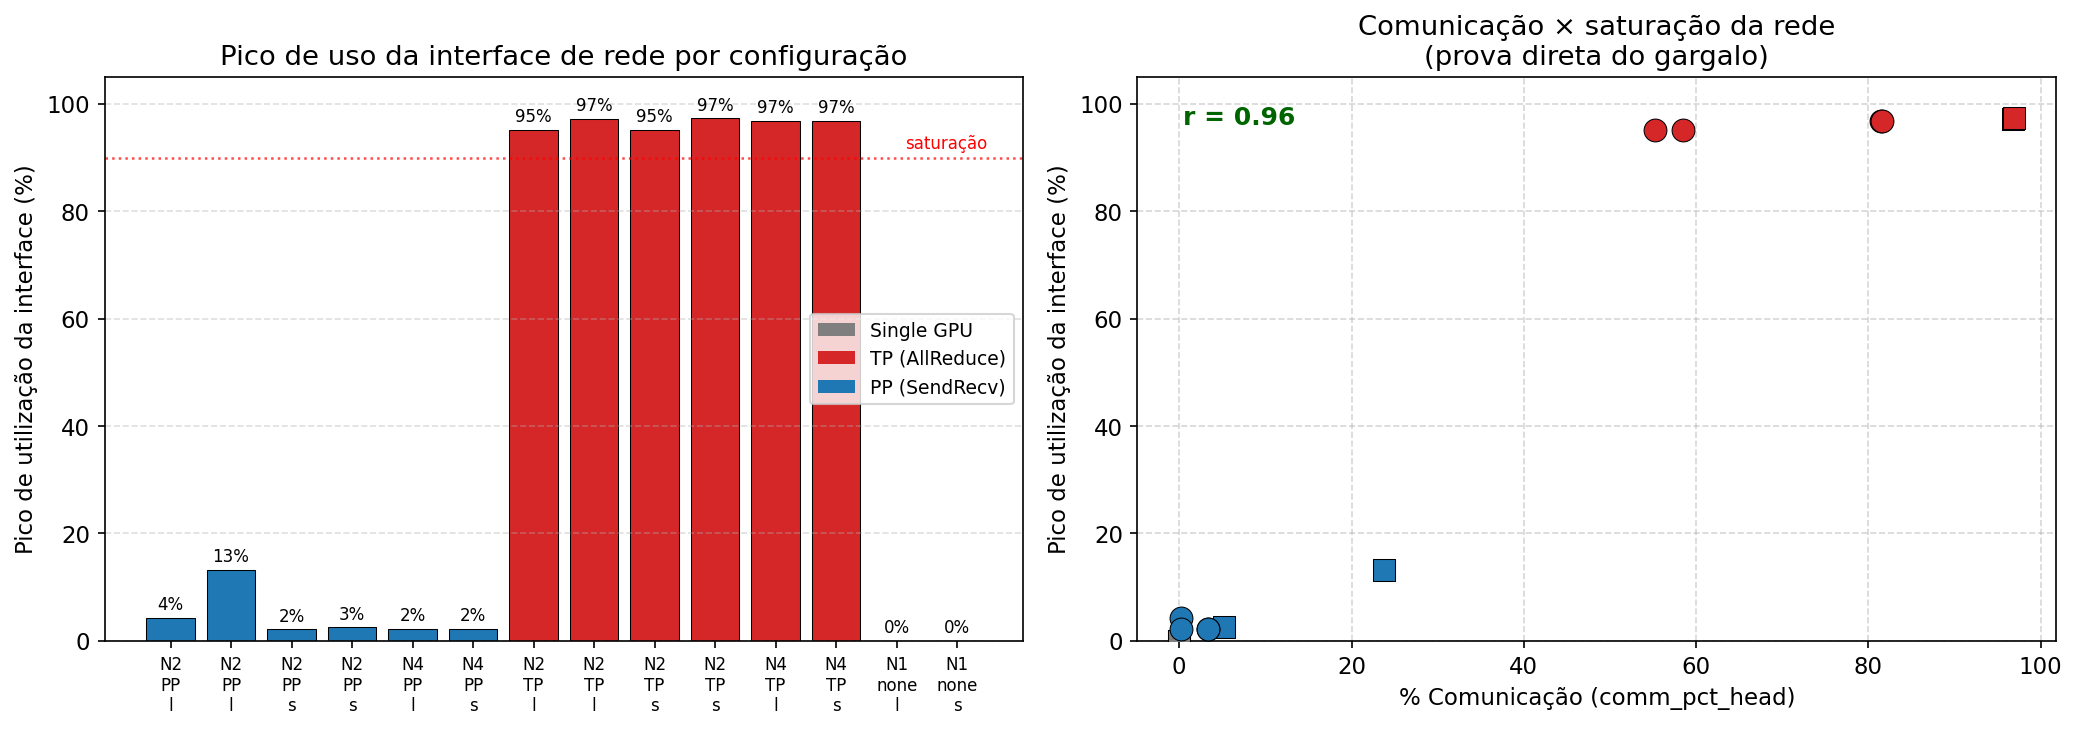

Correlação Pearson r(comm_pct, ifutil_peak) = 0.959 — rede saturada pelo AllReduce do TP.
TP: pico ifutil = 95–97%
PP: pico ifutil = 2–13%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- esquerda: ifutil_peak por config ---
ax = axes[0]
order = cc.sort_values(['strategy', 'n_gpus', 'workload']).reset_index(drop=True)
x = np.arange(len(order))
colors = [STRATEGY_COLORS[s] for s in order['strategy']]
ax.bar(x, order['ifutil_peak'], color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(order['ifutil_peak']):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha='center', fontsize=8)
labels = [f"N{r['n_gpus']}\n{r['strategy']}\n{r['workload'][:1]}" for _, r in order.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Pico de utilização da interface (%)')
ax.set_ylim(0, 105)
ax.axhline(90, color='red', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(len(order)-0.5, 91, 'saturação', ha='right', va='bottom', color='red', fontsize=8)
ax.set_title('Pico de uso da interface de rede por configuração')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# legenda manual
handles = [mpatches.Patch(facecolor=STRATEGY_COLORS[s], label=strategy_label(s))
           for s in ['none', 'TP', 'PP']]
ax.legend(handles=handles, fontsize=9, loc='center right')

# --- direita: scatter comm% x ifutil ---
ax = axes[1]
for _, row in cc.iterrows():
    ax.scatter(row['comm_pct'], row['ifutil_peak'],
               c=STRATEGY_COLORS.get(row['strategy'], 'gray'),
               marker=NODE_MARKER.get(row['node'], 'o'),
               s=120, edgecolors='black', linewidths=0.5, zorder=5)
valid = cc[['comm_pct', 'ifutil_peak']].dropna()
if len(valid) >= 3:
    r = valid.corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            fontsize=12, va='top', color='darkgreen', fontweight='bold')

ax.set_xlabel('% Comunicação (comm_pct_head)')
ax.set_ylabel('Pico de utilização da interface (%)')
ax.set_ylim(0, 105)
ax.set_title('Comunicação × saturação da rede\n(prova direta do gargalo)')
ax.grid(linestyle='--', alpha=0.5)

fig.tight_layout()
fig.savefig(FIG_DIR / 'network-saturation.png', dpi=150, bbox_inches='tight')
plt.show()

if len(valid) >= 3:
    print(f"Correlação Pearson r(comm_pct, ifutil_peak) = {r:.3f} — rede saturada pelo AllReduce do TP.")
    print(f"TP: pico ifutil = {cc[cc['strategy']=='TP']['ifutil_peak'].min():.0f}–{cc[cc['strategy']=='TP']['ifutil_peak'].max():.0f}%")
    print(f"PP: pico ifutil = {cc[cc['strategy']=='PP']['ifutil_peak'].min():.0f}–{cc[cc['strategy']=='PP']['ifutil_peak'].max():.0f}%")

## 4. Escalabilidade da fração de comunicação com N

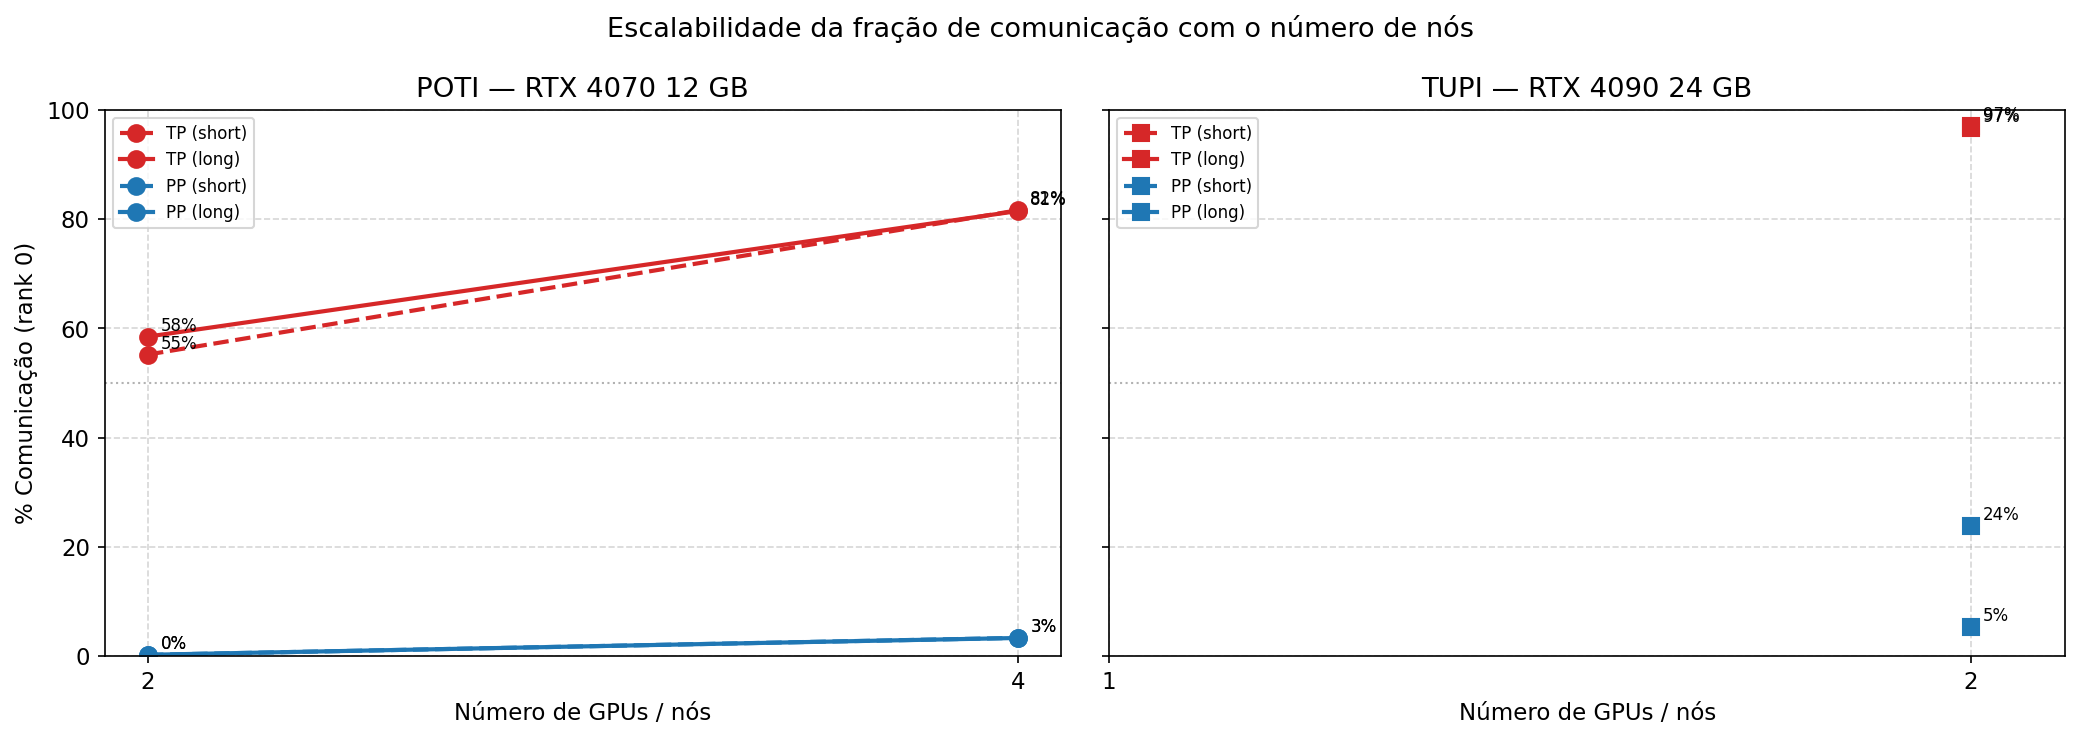

In [7]:
nodes_with_data = [n for n in ['poti', 'tupi'] if n in cc['node'].values]
fig, axes = plt.subplots(1, len(nodes_with_data),
                          figsize=(7 * len(nodes_with_data), 5), sharey=True)
if len(nodes_with_data) == 1:
    axes = [axes]

GPU_NAMES = {'poti': 'RTX 4070 12 GB', 'tupi': 'RTX 4090 24 GB'}

for idx, node in enumerate(nodes_with_data):
    ax = axes[idx]
    node_df = cc[(cc['node'] == node) & (cc['strategy'] != 'none')]

    for strategy in ['TP', 'PP']:
        for wl in ['short', 'long']:
            sub = node_df[(node_df['strategy'] == strategy) & (node_df['workload'] == wl)]\
                         .sort_values('n_gpus')
            if sub.empty:
                continue
            ax.plot(sub['n_gpus'], sub['comm_pct'],
                    marker=NODE_MARKER.get(node, 'o'),
                    color=STRATEGY_COLORS[strategy],
                    linestyle=WORKLOAD_LS.get(wl, '-'),
                    linewidth=2, markersize=8,
                    label=f"{strategy} ({wl})")
            for _, row in sub.iterrows():
                ax.annotate(f"{row['comm_pct']:.0f}%",
                            (row['n_gpus'], row['comm_pct']),
                            textcoords='offset points', xytext=(6, 3), fontsize=8)

    ax.set_title(f"{node.upper()} — {GPU_NAMES.get(node, '')}")
    ax.set_xlabel('Número de GPUs / nós')
    ax.set_ylabel('% Comunicação (rank 0)' if idx == 0 else '')
    all_n = sorted(cc[cc['node'] == node]['n_gpus'].unique())
    ax.set_xticks(all_n)
    ax.set_ylim(0, 100)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.5)

fig.suptitle('Escalabilidade da fração de comunicação com o número de nós', fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'comm-fraction-scaling.png', dpi=150, bbox_inches='tight')
plt.show()

Há um claro aumento da fração de tempo em comunicação com o aumento do número de nós, o que é esperado: mais nós significam mais partições sincronizando entre si, seja via AllReduce (TP) ou via troca de ativações entre estágios (PP).

## 5. Correlação: fração de comunicação × métricas de performance

Se a hipótese de gargalo de comunicação estiver correta, esperamos:
- Correlação **positiva** entre `comm_pct` e `itl_ms`, `ttft_ms`, `latency_ms`
  (mais comunicação → maior latência).
- Correlação **negativa** entre `comm_pct` e `throughput_req_s`
  (mais comunicação → menor throughput).

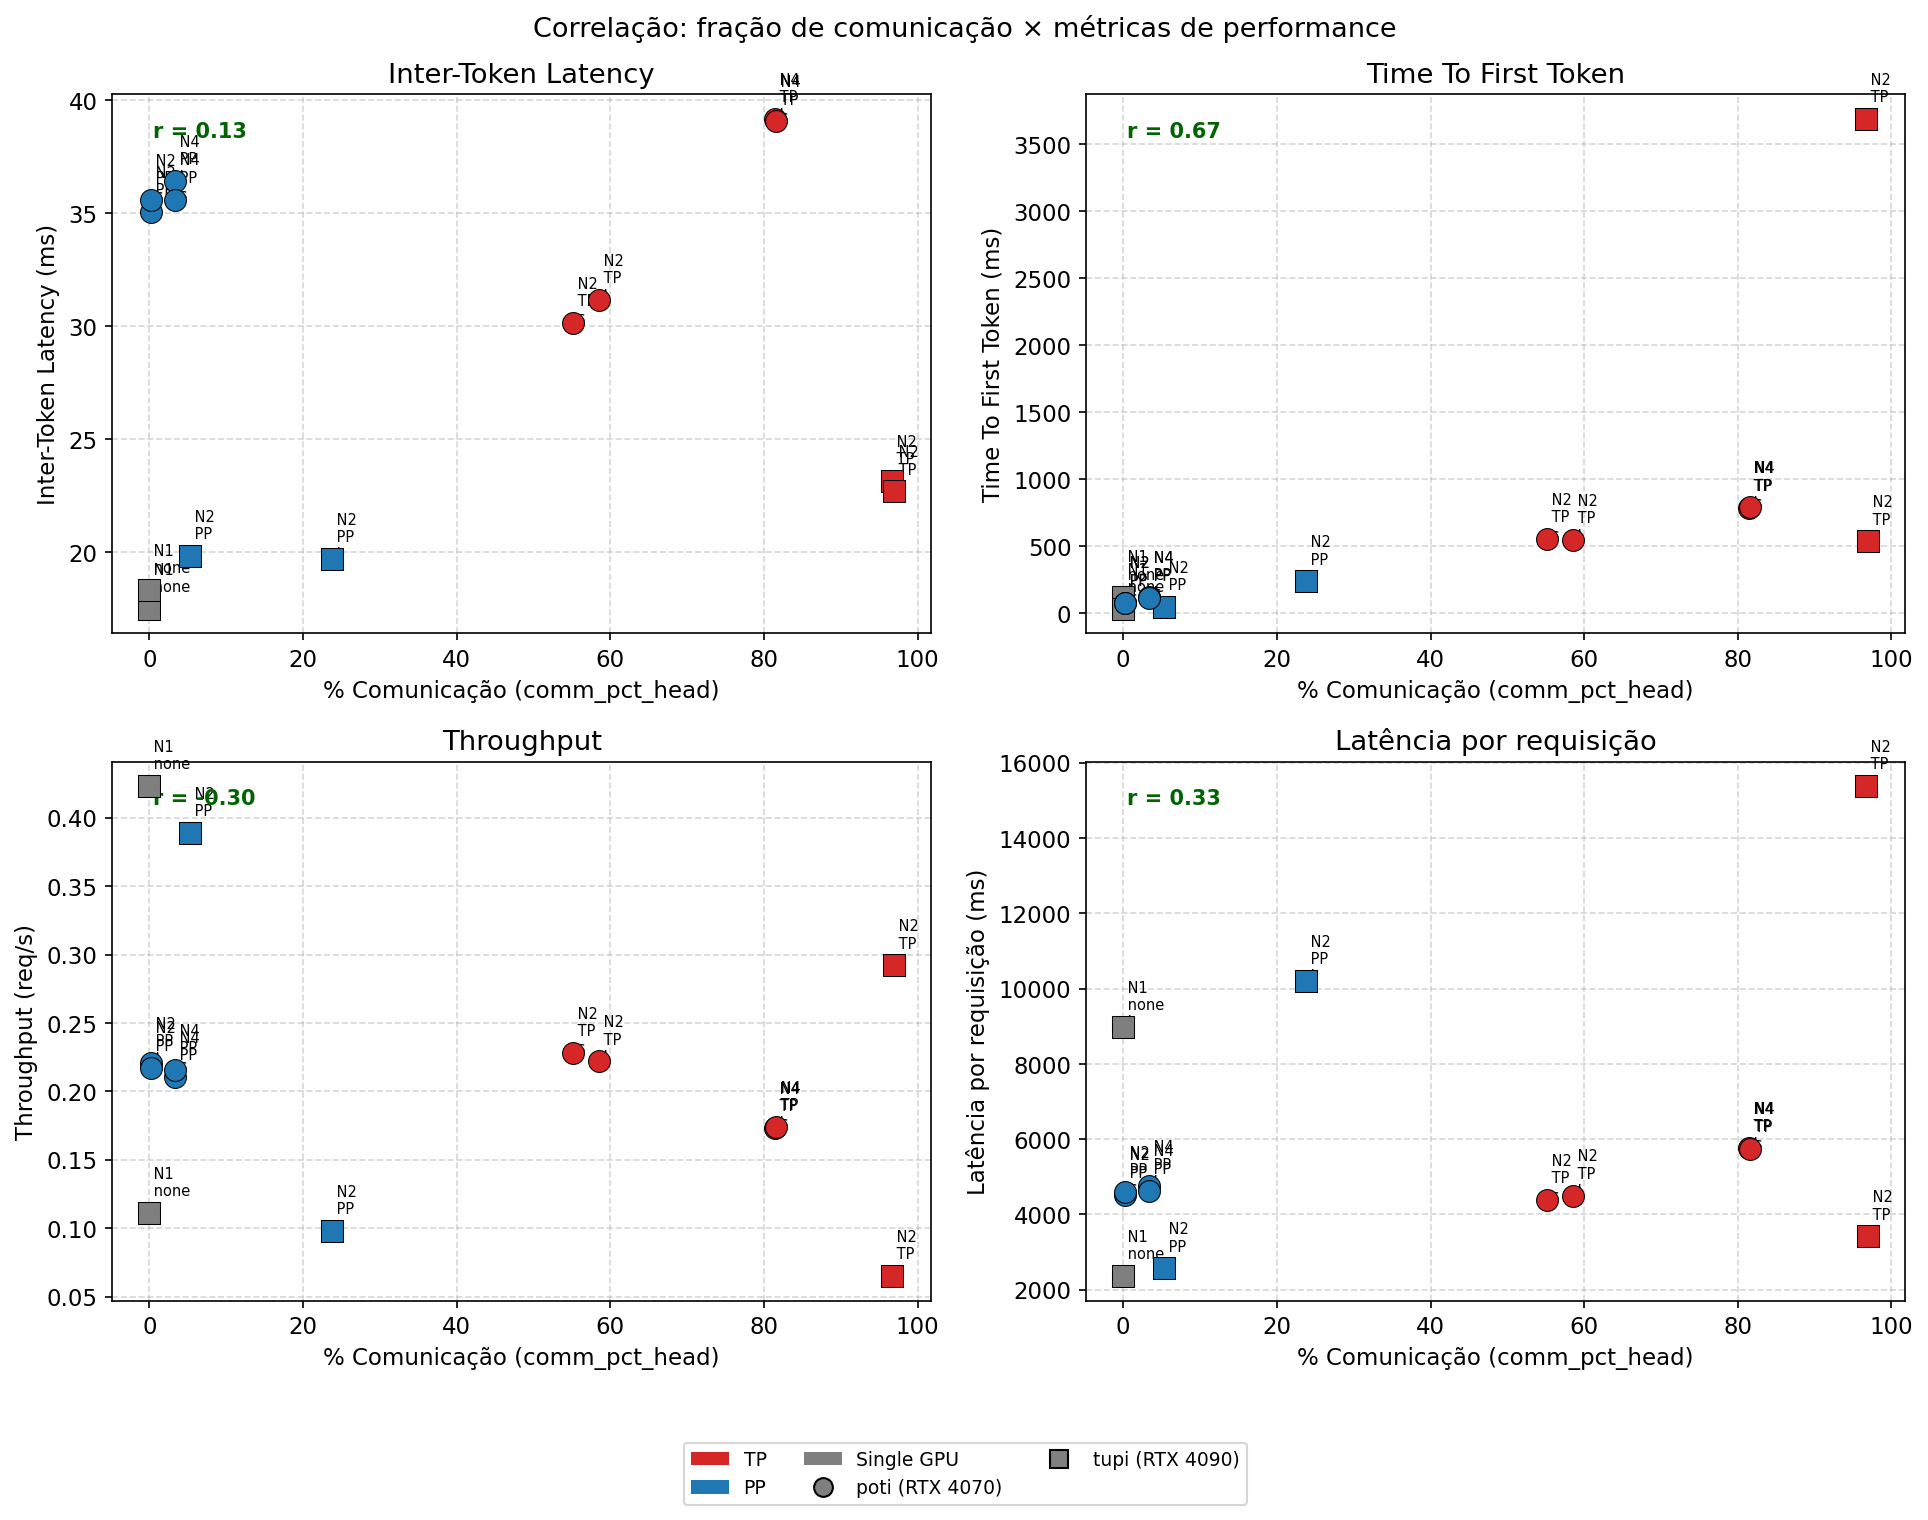

In [8]:
METRICS = [
    ('itl_ms',           'Inter-Token Latency (ms)',    True),
    ('ttft_ms',          'Time To First Token (ms)',     True),
    ('throughput_req_s', 'Throughput (req/s)',           False),
    ('latency_ms',       'Latência por requisição (ms)', True),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (col, ylabel, higher_is_worse) in zip(axes, METRICS):
    sub = cc[cc[col].notna()].copy()
    for _, row in sub.iterrows():
        c = STRATEGY_COLORS.get(row['strategy'], 'gray')
        m = NODE_MARKER.get(row['node'], 'o')
        ax.scatter(row['comm_pct'], row[col], c=c, marker=m,
                   s=110, edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(
            f" N{int(row['n_gpus'])}\n {row['strategy']}\n {row['workload'][:1]}",
            (row['comm_pct'], row[col]), fontsize=7
        )

    if len(sub) >= 3:
        r = sub[['comm_pct', col]].dropna().corr().iloc[0, 1]
        expected_sign = r > 0 if higher_is_worse else r < 0
        color = 'darkgreen' if expected_sign else 'gray'
        ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
                fontsize=10, va='top', color=color, fontweight='bold')

    ax.set_xlabel('% Comunicação (comm_pct_head)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split('(')[0].strip())
    ax.grid(linestyle='--', alpha=0.5)

legend_elements = [
    mpatches.Patch(facecolor=STRATEGY_COLORS['TP'],   label='TP'),
    mpatches.Patch(facecolor=STRATEGY_COLORS['PP'],   label='PP'),
    mpatches.Patch(facecolor=STRATEGY_COLORS['none'], label='Single GPU'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='black', label='poti (RTX 4070)', markersize=9),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='black', label='tupi (RTX 4090)', markersize=9),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Correlação: fração de comunicação × métricas de performance', fontsize=13)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(FIG_DIR / 'comm-perf-correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Quanto ao TTFT, observa-se uma correlação positiva forte ($r = 0{,}67$), indicando que, à medida que a comunicação aumenta, o TTFT também tende a aumentar. Já para as demais métricas, as correlações foram fraca para o ITL ($r = 0{,}13$) e baixas para o throughput ($r = 0{,}30$) e a latência por requisição ($r = 0{,}33$), não evidenciando uma relação tão clara. Essa classificação segue os critérios propostos por Hinkle, Wiersma e Jurs (2003). Apesar de mostrar uma performance parecida quanto a estas métricas, o fato de o TTFT demorar cerca de 2 a 5 vezes mais tende a equiparar as latências totais das duas estratégias.

**Referência**

HINKLE, Dennis E.; WIERSMA, William; JURS, Stephen G. *Applied statistics for the behavioral sciences*. 5. ed. Boston: Houghton Mifflin, 2003.

In [9]:
tp_df = cc[cc['strategy'] == 'TP'].copy()

# Calcula speedup de banda necessário
tp_df['speedup_needed'] = (
    tp_df['comm_pct'] * (100 - TARGET_PCT) / (tp_df['comp_pct'] * TARGET_PCT)
)

# Referência de banda
if tp_df['iperf3_gbps'].notna().any():
    tp_df['ref_bw'] = tp_df['iperf3_gbps'].fillna(ASSUMED_BW_GBPS)
    bw_source = "iperf3 medido"
else:
    tp_df['ref_bw'] = ASSUMED_BW_GBPS
    bw_source = f"estimado {ASSUMED_BW_GBPS} Gbps (10GbE — referência típica PCAD)"

tp_df['ideal_gbps'] = tp_df['speedup_needed'] * tp_df['ref_bw']

print(f"Banda de referência: {bw_source}")
print(f"Alvo de comunicação: ≤{TARGET_PCT}% (abaixo disso = compute-bound)")
print()
print(tp_df[['run', 'n_gpus', 'workload', 'comm_pct', 'ref_bw',
             'speedup_needed', 'ideal_gbps']].to_string(index=False, float_format='{:.1f}'.format))

Banda de referência: iperf3 medido
Alvo de comunicação: ≤20% (abaixo disso = compute-bound)

                       run  n_gpus workload  comm_pct  ref_bw  speedup_needed  ideal_gbps
 N2_poti_TP_long_r1_790072       2     long      58.5     0.9             5.6         5.3
 N2_tupi_TP_long_r1_798983       2     long      96.7     0.9           118.3       111.4
N2_poti_TP_short_r1_790073       2    short      55.2     0.9             4.9         4.6
N2_tupi_TP_short_r1_796872       2    short      96.9     0.9           126.9       119.4
 N4_poti_TP_long_r1_790077       4     long      81.5     0.9            17.6        16.5
N4_poti_TP_short_r1_790075       4    short      81.6     0.9            17.7        16.7


Os resultados indicam um forte gargalo de comunicação em todos os cenários, com fração de tempo de comunicação variando de aproximadamente 55% até 97%, o que caracteriza sistemas predominantemente communication-bound. O caso da Tupi é o mais crítico, exigindo um speedup de largura de banda da ordem de 100× ou mais para atingir o alvo de 20% de overhead de comunicação, o que implica uma necessidade de rede na faixa de 100+ Gbps, fora do alcance de upgrades convencionais. Já a Poti apresenta menor severidade, com necessidade de speedups entre ~5× (2 GPUs) e ~17× (4 GPUs), indicando que melhorias de rede poderiam trazer ganhos relevantes, embora ainda exista limitação. Observa-se também que o aumento do número de GPUs piora a eficiência de comunicação, sugerindo escalabilidade desfavorável do paralelismo adotado e possível ausência de sobreposição eficiente entre comunicação e computação.


## 6. Análise Estatística — Modelo de custo de rede

Métricas-resposta: **request throughput** e **TTFT** (Time to First Token).

Pergunta central: **que rede PCAD tornaria o paralelismo TP vantajoso?** — Modelo de
break-even calibrado empiricamente, projetado sobre 1 GbE → 100 GbE → NVLink.

**Dados:** `data_processed/summary.csv` (trace, conc=1 — baseline do break-even).

In [10]:
from __future__ import annotations
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "figures" / "statistical_analysis"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "font.size": 13})
print(f"ROOT = {ROOT}")

ROOT = /home/matheus/mestrado/perf/vllm-parallelism-benchmark


### Modelo de custo: que rede tornaria TP vantajoso?

$$\text{TTFT}_{\text{TP}}(B) = T_{\text{comp}} + \frac{K}{B}$$

- $T_{\text{comp}} \approx \text{TTFT}_{\text{single}}$ — no limite $B \to \infty$, o tempo
  dominante é a computação (sem AllReduce overhead)
- $K$ é calibrado pelo ponto medido em 1 GbE:
  $K = (\text{TTFT}_{\text{TP}}^{\text{1GbE}} - T_{\text{comp}}) \times B_{\text{medida}}$
- **Break-even TP = PP:** $B = K / (\text{TTFT}_{\text{PP}} - T_{\text{comp}})$

In [11]:
# Baseline do trace (conc=1): TTFT e throughput por estratégia — calibra o break-even
summary = pd.read_csv(ROOT / "data_processed" / "summary.csv")
df = summary.copy()
df["strategy"] = df["parallelism"].str.replace("Single GPU", "single").str.lower()
df["wl"] = df["experiment_name"].str.contains("_long_").map({True: "long", False: "short"})
df["machine"] = df["machine_name"].str.lower().str.split(r"[\[\],]").str[0]
df.loc[df["experiment_name"].str.contains("tupi"), "machine"] = "tupi"
df.loc[df["experiment_name"].str.contains("poti"), "machine"] = "poti"
df["n_nodes"] = df["n_nodes"].astype(int)
df["throughput"] = df["request_throughput_avg"].astype(float)
df["ttft"] = df["time_to_first_token_avg_ms"].astype(float)
df_tp_pp = df[df["strategy"].isin(["tp", "pp"])].copy()
print(f"Trace baseline: {len(df)} observações ({len(df_tp_pp)} TP/PP)")


Trace baseline: 14 observações (12 TP/PP)


In [12]:
B_MEAS_GBS = 0.941  # iperf3 medido em tupi
single_ttft_map = df[df["strategy"] == "single"].set_index("wl")["ttft"].to_dict()
single_thr_map = df[df["strategy"] == "single"].set_index("wl")["throughput"].to_dict()

rows_be = []
for (n, mac, wl), g in df_tp_pp.groupby(["n_nodes", "machine", "wl"]):
    tp = g[g["strategy"] == "tp"]; pp = g[g["strategy"] == "pp"]
    if len(tp) == 0 or len(pp) == 0: continue
    TTFT_TP = float(tp["ttft"].iloc[0]); TTFT_PP = float(pp["ttft"].iloc[0])
    TTFT_single = single_ttft_map.get(wl, np.nan)
    THR_TP = float(tp["throughput"].iloc[0]); THR_single = single_thr_map.get(wl, np.nan)
    K = (TTFT_TP - TTFT_single) * B_MEAS_GBS
    B_be_lat = K / (TTFT_PP - TTFT_single) if TTFT_PP > TTFT_single else np.nan
    B_be_thr = (THR_single / THR_TP) * B_MEAS_GBS if THR_TP > 0 else np.nan
    rows_be.append({"config": f"N={n} {mac} {wl}", "TTFT_TP_1GbE_ms": round(TTFT_TP, 1),
                     "TTFT_PP_ms": round(TTFT_PP, 1), "TTFT_single_ms": round(TTFT_single, 1),
                     "K_Gb_ms": round(K, 1),
                     "B_TP_eq_PP_TTFT_Gbs": round(B_be_lat, 1) if np.isfinite(B_be_lat) else None,
                     "B_TP_eq_single_THR_Gbs": round(B_be_thr, 1) if np.isfinite(B_be_thr) else None})
be_df = pd.DataFrame(rows_be)
B_lat_vals = [r["B_TP_eq_PP_TTFT_Gbs"] for r in rows_be if r["B_TP_eq_PP_TTFT_Gbs"] is not None]
B_thr_vals = [r["B_TP_eq_single_THR_Gbs"] for r in rows_be if r["B_TP_eq_single_THR_Gbs"] is not None]
B_lat_med = np.median(B_lat_vals); B_thr_med = np.median(B_thr_vals)
print(f"Break-even TP=PP (latência TTFT):        mediana = {B_lat_med:.1f} Gbit/s")
print(f"Break-even TP=Single (throughput):        mediana = {B_thr_med:.1f} Gbit/s")
be_df


Break-even TP=PP (latência TTFT):        mediana = 20.0 Gbit/s
Break-even TP=Single (throughput):        mediana = 1.5 Gbit/s


,config,TTFT_TP_1GbE_ms,TTFT_PP_ms,TTFT_single_ms,K_Gb_ms,B_TP_eq_PP_TTFT_Gbs,B_TP_eq_single_THR_Gbs
0,N=2 poti long,547.1,80.3,125.0,397.2,NaN,0.5
1,N=2 poti short,552.5,79.8,32.2,489.6,10.3,1.7
2,N=2 tupi long,3689.1,238.1,125.0,3353.8,29.7,1.6
3,N=2 tupi short,536.7,47.6,32.2,474.7,30.9,1.4
4,N=4 poti long,789.1,119.9,125.0,624.9,NaN,0.6
5,N=4 poti short,789.9,117.5,32.2,713.0,8.4,2.3


In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
mask = (df_tp_pp["wl"] == "long")
for (n, mac), g in df_tp_pp[mask].groupby(["n_nodes", "machine"]):
    tp = g[g["strategy"] == "tp"]; pp = g[g["strategy"] == "pp"]
    if len(tp) == 0 or len(pp) == 0: continue
    TTFT_TP = float(tp["ttft"].iloc[0]); TTFT_PP = float(pp["ttft"].iloc[0])
    TTFT_single = single_ttft_map["long"]
    K = (TTFT_TP - TTFT_single) * B_MEAS_GBS
    B = np.logspace(np.log10(0.5), np.log10(700), 200)
    ax.loglog(B, TTFT_single + K / B, "-", lw=2.5, alpha=0.85, label=f"TP N={n} {mac}")
    ax.axhline(TTFT_PP, ls="--", lw=1.2, alpha=0.45, color="#1f77b4")
    ax.plot(B_MEAS_GBS, TTFT_TP, "o", color="#d62728", markersize=11,
            markeredgecolor="black", markeredgewidth=0.8, zorder=5)
ax.axhline(TTFT_single, color="#2ca02c", ls=":", lw=2.2, label=f"Single GPU ({TTFT_single:.0f} ms)")
for (n, mac), g in df_tp_pp[mask].groupby(["n_nodes", "machine"]):
    pp = g[g["strategy"] == "pp"]
    if len(pp) == 0: continue
    ax.text(700, float(pp["ttft"].iloc[0]), f" PP N={n} {mac}", va="center", fontsize=9, color="#1f77b4")
ax.axvline(B_MEAS_GBS, color="black", alpha=0.5, lw=1)
ax.text(B_MEAS_GBS * 1.05, 4, "1 GbE\n(PCAD)", fontsize=10)
techs = [("1 GbE", 0.941), ("10 GbE", 9.4), ("25 GbE", 23.5), ("100 GbE\n(IB HDR)", 94), ("NVLink", 600)]
for name, b in techs:
    ax.axvline(b, color="gray", ls="-", alpha=0.18, lw=1)
    ax.text(b, 1.5, name, fontsize=8, rotation=90, va="bottom", ha="center", color="dimgray")
if np.isfinite(B_lat_med):
    ax.axvline(B_lat_med, color="#1f77b4", alpha=0.25, lw=10)
    ax.text(B_lat_med * 1.05, 1000, f"TP=PP\n{B_lat_med:.0f} Gb/s", color="#1f77b4", fontsize=10, weight="bold")
ax.set_xlabel("Banda da interconexão (Gbit/s, log)"); ax.set_ylabel("TTFT (ms, log)")
ax.set_title("Projeção: TTFT do TP vs banda de rede\n(workload long, Qwen2.5-7B-Instruct)")
ax.legend(loc="lower left", fontsize=10); ax.grid(True, which="both", alpha=0.3)
ax.set_xlim(0.5, 800); ax.set_ylim(1, 10000)
plt.suptitle(f"Recomendação de rede para paralelismo TP (break-even ≈ {B_lat_med:.0f} Gb/s)",
             y=1.03, fontsize=14, weight="bold")
plt.tight_layout(); plt.savefig(FIG / "network_break_even.png"); plt.close()
print("salvo:", FIG / "network_break_even.png")


salvo: /home/matheus/mestrado/perf/vllm-parallelism-benchmark/figures/statistical_analysis/network_break_even.png


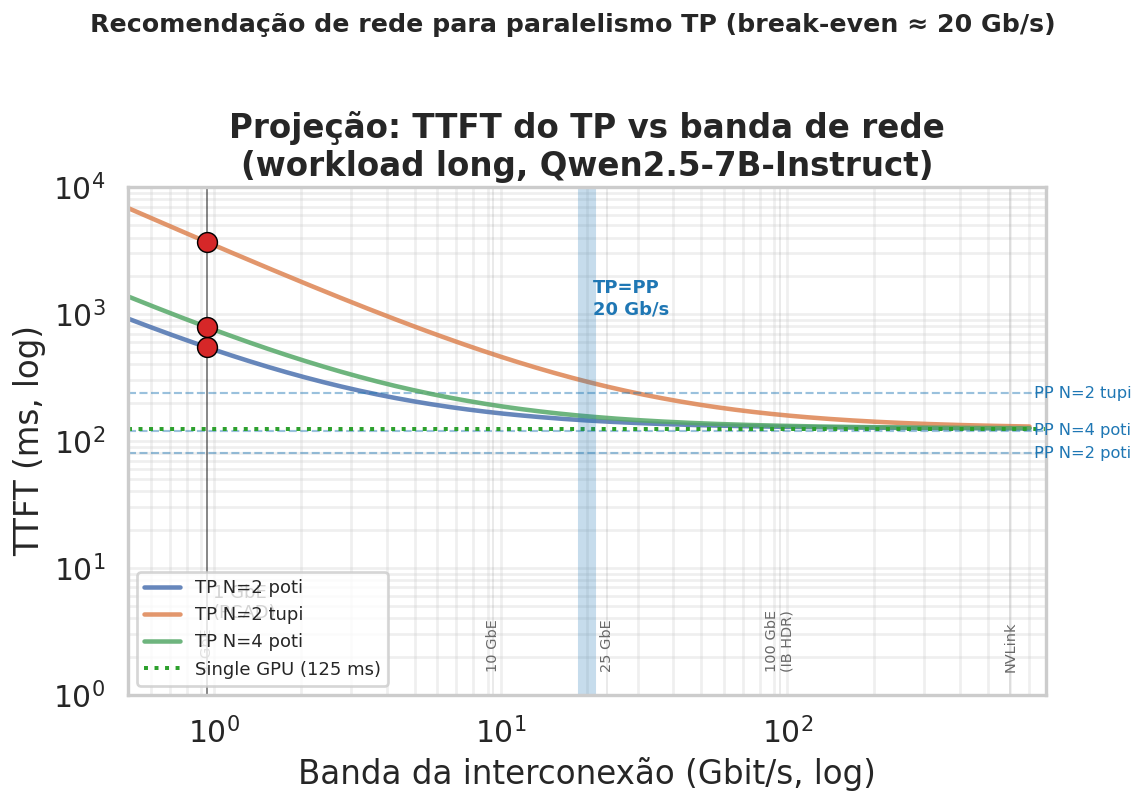

In [14]:
display(Image(filename=str(FIG / "network_break_even.png")))


In [15]:
be_summary = pd.DataFrame([{
    "metrica_alvo": "TP = PP (latência TTFT)",
    "banda_Gbit_s_mediana": round(B_lat_med, 1) if np.isfinite(B_lat_med) else None,
    "tecnologia_equivalente": "10 GbE" if B_lat_med < 12 else ("25 GbE" if B_lat_med < 25 else "100 GbE (IB)"),
}, {
    "metrica_alvo": "TP = Single GPU (throughput)",
    "banda_Gbit_s_mediana": round(B_thr_med, 1) if np.isfinite(B_thr_med) else None,
    "tecnologia_equivalente": "10 GbE" if B_thr_med < 12 else ("25 GbE" if B_thr_med < 25 else "100 GbE (IB)"),
}])
be_summary.to_csv(ROOT / "data_processed" / "network_break_even.csv", index=False)
print("CSV salvo em data_processed/network_break_even.csv")
print(be_summary.to_string(index=False))


CSV salvo em data_processed/network_break_even.csv
                metrica_alvo  banda_Gbit_s_mediana tecnologia_equivalente
     TP = PP (latência TTFT)                  20.0                 25 GbE
TP = Single GPU (throughput)                   1.5                 10 GbE
